In [1]:
import pandas as pd

df = pd.read_csv('2019-Oct.csv')

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


smartphone df 생성

In [2]:
smartphone_df = df[df['category_code'] == 'electronics.smartphone'].copy()

----------------------------

단순 view / purchase 파악 -> 브랜드 인기(노출도)

In [3]:
brand_view = (
    smartphone_df[smartphone_df['event_type'] == 'view']
    .groupby('brand')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='view_count')
)

brand_view.head(10)

,brand,view_count
0,samsung,3386871
1,apple,2991772
2,xiaomi,2094234
3,huawei,940176
4,oppo,451449
5,meizu,152984
6,vivo,108180
7,honor,75499
8,nokia,69428
9,sony,66547


In [5]:
#비율
brand_view_ratio = brand_view.copy()
brand_view_ratio['ratio'] = brand_view_ratio['view_count'] / brand_view_ratio['view_count'].sum()

brand_view_ratio.head(10)

,brand,view_count,ratio
0,samsung,3386871,0.319565
1,apple,2991772,0.282286
2,xiaomi,2094234,0.197600
3,huawei,940176,0.088709
4,oppo,451449,0.042596
5,meizu,152984,0.014435
6,vivo,108180,0.010207
7,honor,75499,0.007124
8,nokia,69428,0.006551
9,sony,66547,0.006279


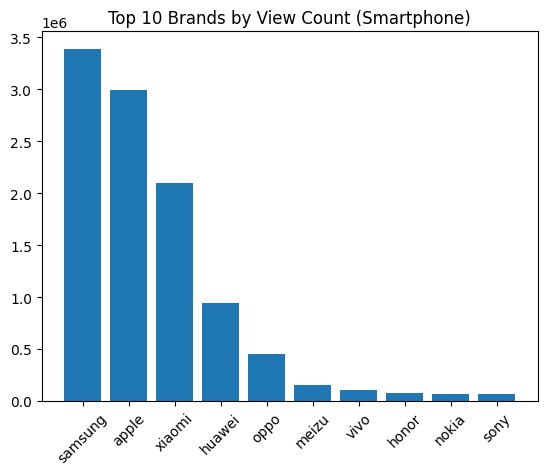

In [7]:
#시각화
import matplotlib.pyplot as plt

top10 = brand_view.head(10)

plt.figure()
plt.bar(top10['brand'], top10['view_count'])
plt.xticks(rotation=45)
plt.title('Top 10 Brands by View Count (Smartphone)')
plt.show()

In [8]:
brand_purchase = (
    smartphone_df[smartphone_df['event_type'] == 'purchase']
    .groupby('brand')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='purchase_count')
)

brand_purchase.head(10)

,brand,purchase_count
0,samsung,143123
1,apple,115345
2,xiaomi,38776
3,huawei,21882
4,oppo,10891
5,vivo,2025
6,meizu,1686
7,honor,555
8,nokia,512
9,oneplus,509


In [9]:
brand_purchase_ratio = brand_purchase.copy()
brand_purchase_ratio['ratio'] = (
    brand_purchase_ratio['purchase_count'] / brand_purchase_ratio['purchase_count'].sum()
)

brand_purchase_ratio.head(10)

,brand,purchase_count,ratio
0,samsung,143123,0.423974
1,apple,115345,0.341687
2,xiaomi,38776,0.114866
3,huawei,21882,0.064821
4,oppo,10891,0.032262
5,vivo,2025,0.005999
6,meizu,1686,0.004994
7,honor,555,0.001644
8,nokia,512,0.001517
9,oneplus,509,0.001508


In [10]:
brand_revenue_detail = (
    smartphone_df[smartphone_df['event_type'] == 'purchase']
    .groupby('brand')
    .agg(
        revenue=('price', 'sum'),
        purchase_count=('price', 'count'),
        avg_price=('price', 'mean')
    )
    .sort_values(by='revenue', ascending=False)
    .reset_index()
)

brand_revenue_detail.head(10)

,brand,revenue,purchase_count,avg_price
0,apple,1.025490e+08,115345,889.063293
1,samsung,3.737366e+07,143123,261.129673
2,xiaomi,8.059770e+06,38776,207.854606
3,huawei,4.702812e+06,21882,214.916896
4,oppo,2.412960e+06,10891,221.555391
5,vivo,4.956786e+05,2025,244.779556
6,oneplus,3.510762e+05,509,689.737171
7,meizu,2.123246e+05,1686,125.933909
8,sony,1.675179e+05,494,339.105162
9,honor,1.374848e+05,555,247.720270


-------------------------------------------

세션 기준 브랜드 퍼널 분류

In [ ]:
#정렬 + unknown처리
df = smartphone_df.sort_values(['user_session', 'event_time']).copy()
df['brand'] = df['brand'].fillna('unknown')

In [ ]:
grouped = df.groupby(['user_session', 'brand'])

#grouped = df.groupby(['user_session', 'user_id', 'product_id', 'brand'])

In [19]:
result = []
for (session, brand), group in grouped:
    group = group.sort_values('event_time')  
    events = group['event_type'].tolist()

    
    # index 찾기
    view_idx = next((i for i, e in enumerate(events) if e == 'view'), None)
    cart_idx = next((i for i, e in enumerate(events) if e == 'cart'), None)
    purchase_idx = next((i for i, e in enumerate(events) if e == 'purchase'), None)
    
    has_view = view_idx is not None
    valid_view_cart = view_idx is not None and cart_idx is not None and view_idx < cart_idx
    valid_cart_purchase = cart_idx is not None and purchase_idx is not None and cart_idx < purchase_idx
    
    result.append([
        session, brand,
        has_view,
        valid_view_cart,
        valid_cart_purchase
    ])

funnel_df = pd.DataFrame(result, columns=[
    'user_session', 'brand',
    'view', 'view_to_cart', 'cart_to_purchase'
])

In [20]:
import numpy as np
import pandas as pd

# 브랜드별 퍼널 집계
brand_funnel = (
    funnel_df.groupby('brand')
    .agg(
        view_sessions=('view', 'sum'),
        view_to_cart_sessions=('view_to_cart', 'sum'),
        cart_to_purchase_sessions=('cart_to_purchase', 'sum')
    )
    .reset_index()
)

# 전환율 계산
brand_funnel['view_to_cart_rate'] = np.where(
    brand_funnel['view_sessions'] > 0,
    brand_funnel['view_to_cart_sessions'] / brand_funnel['view_sessions'],
    0
)

brand_funnel['cart_to_purchase_rate'] = np.where(
    brand_funnel['view_to_cart_sessions'] > 0,
    brand_funnel['cart_to_purchase_sessions'] / brand_funnel['view_to_cart_sessions'],
    0
)

brand_funnel['total_conversion_rate'] = np.where(
    brand_funnel['view_sessions'] > 0,
    brand_funnel['cart_to_purchase_sessions'] / brand_funnel['view_sessions'],
    0
)

# 이탈률
brand_funnel['drop_view_to_cart'] = 1 - brand_funnel['view_to_cart_rate']
brand_funnel['drop_cart_to_purchase'] = 1 - brand_funnel['cart_to_purchase_rate']

# 표본 적은 브랜드 제거
brand_funnel = brand_funnel[brand_funnel['view_sessions'] >= 100].copy()

# 매출 데이터 결합
brand_revenue = (
    smartphone_df[smartphone_df['event_type'] == 'purchase']
    .groupby('brand')
    .agg(
        revenue=('price', 'sum'),
        purchase_count=('price', 'count'),
        avg_price=('price', 'mean')
    )
    .reset_index()
)

brand_analysis = brand_funnel.merge(
    brand_revenue,
    on='brand',
    how='left'
).fillna(0)

# 보기 좋게 정렬
brand_analysis = brand_analysis.sort_values(
    by='total_conversion_rate',
    ascending=False
)

# 퍼센트 변환
rate_cols = [
    'view_to_cart_rate',
    'cart_to_purchase_rate',
    'total_conversion_rate',
    'drop_view_to_cart',
    'drop_cart_to_purchase'
]

brand_analysis[rate_cols] = brand_analysis[rate_cols] * 100

brand_analysis.head(20)

,brand,view_sessions,view_to_cart_sessions,cart_to_purchase_sessions,view_to_cart_rate,cart_to_purchase_rate,total_conversion_rate,drop_view_to_cart,drop_cart_to_purchase,revenue,purchase_count,avg_price
27,samsung,1260159,149394,86443,11.855171,57.862431,6.859690,88.144829,42.137569,3.737366e+07,143123.0,261.129673
0,apple,1169945,108004,57385,9.231545,53.132291,4.904931,90.768455,46.867709,1.025490e+08,115345.0,889.063293
23,oppo,177602,12864,7250,7.243162,56.358831,4.082161,92.756838,43.641169,2.412960e+06,10891.0,221.555391
11,huawei,343957,24634,13300,7.161942,53.990420,3.866762,92.838058,46.009580,4.702812e+06,21882.0,214.916896
36,xiaomi,634709,40529,18029,6.385446,44.484197,2.840514,93.614554,55.515803,8.059770e+06,38776.0,207.854606
35,vivo,41397,1949,1031,4.708071,52.898923,2.490519,95.291929,47.101077,4.956786e+05,2025.0,244.779556
26,prestigio,7132,224,110,3.140774,49.107143,1.542344,96.859226,50.892857,1.583360e+04,287.0,55.169338
37,zte,6030,158,63,2.620232,39.873418,1.044776,97.379768,60.126582,1.362387e+04,173.0,78.750694
33,unknown,12876,252,128,1.957130,50.793651,0.994098,98.042870,49.206349,0.000000e+00,0.0,0.000000
14,jinga,2512,57,22,2.269108,38.596491,0.875796,97.730892,61.403509,2.734110e+03,43.0,63.583953


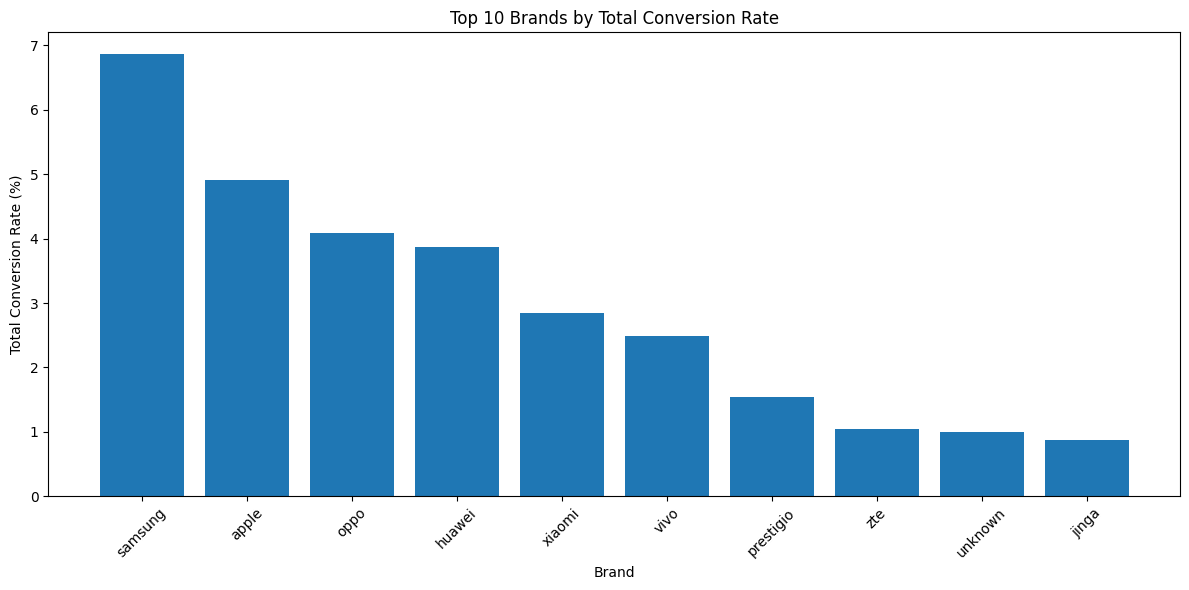

In [21]:
import matplotlib.pyplot as plt

top10_conv = brand_analysis.sort_values(
    by='total_conversion_rate', ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_conv['brand'], top10_conv['total_conversion_rate'])
plt.xticks(rotation=45)
plt.title('Top 10 Brands by Total Conversion Rate')
plt.xlabel('Brand')
plt.ylabel('Total Conversion Rate (%)')
plt.tight_layout()
plt.show()

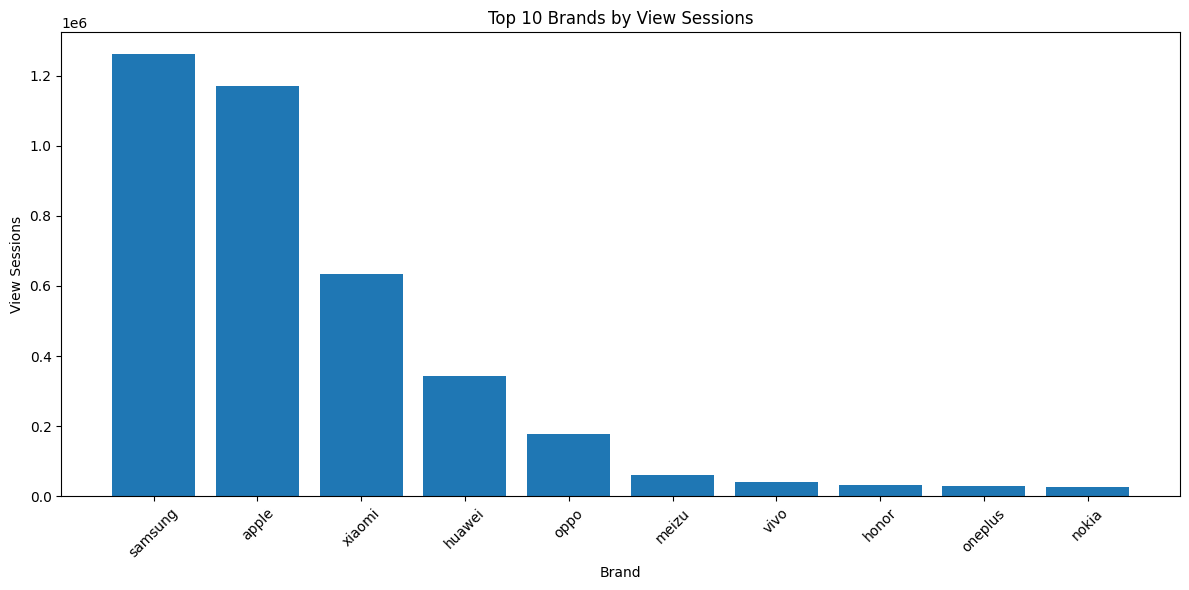

In [22]:
top10_view = brand_analysis.sort_values(
    by='view_sessions', ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_view['brand'], top10_view['view_sessions'])
plt.xticks(rotation=45)
plt.title('Top 10 Brands by View Sessions')
plt.xlabel('Brand')
plt.ylabel('View Sessions')
plt.tight_layout()
plt.show()

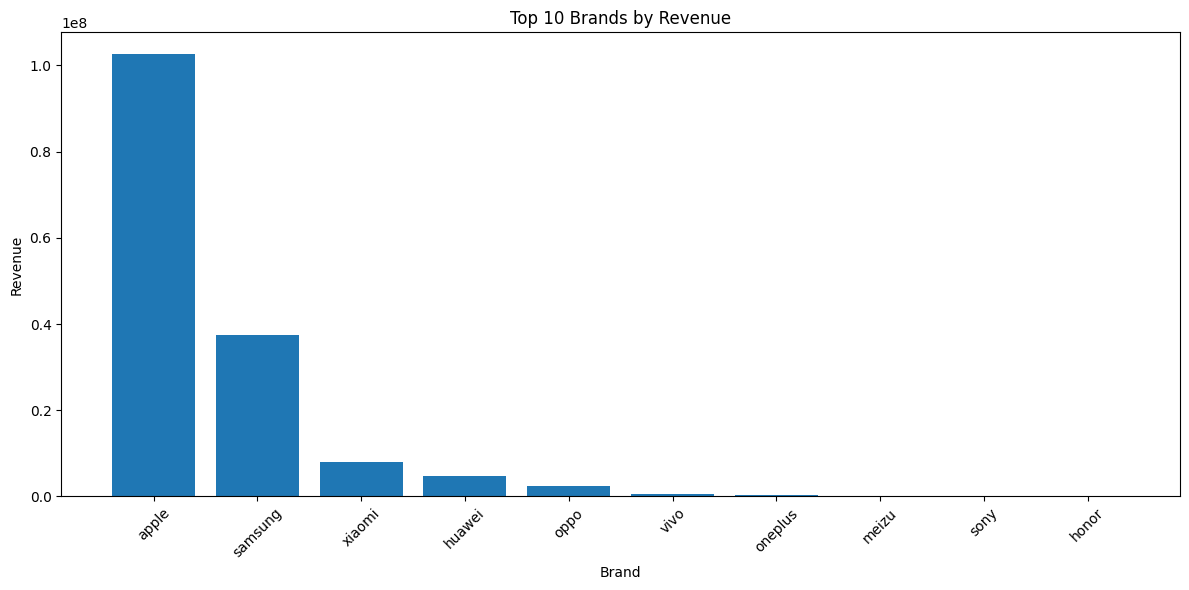

In [23]:
top10_revenue = brand_analysis.sort_values(
    by='revenue', ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_revenue['brand'], top10_revenue['revenue'])
plt.xticks(rotation=45)
plt.title('Top 10 Brands by Revenue')
plt.xlabel('Brand')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

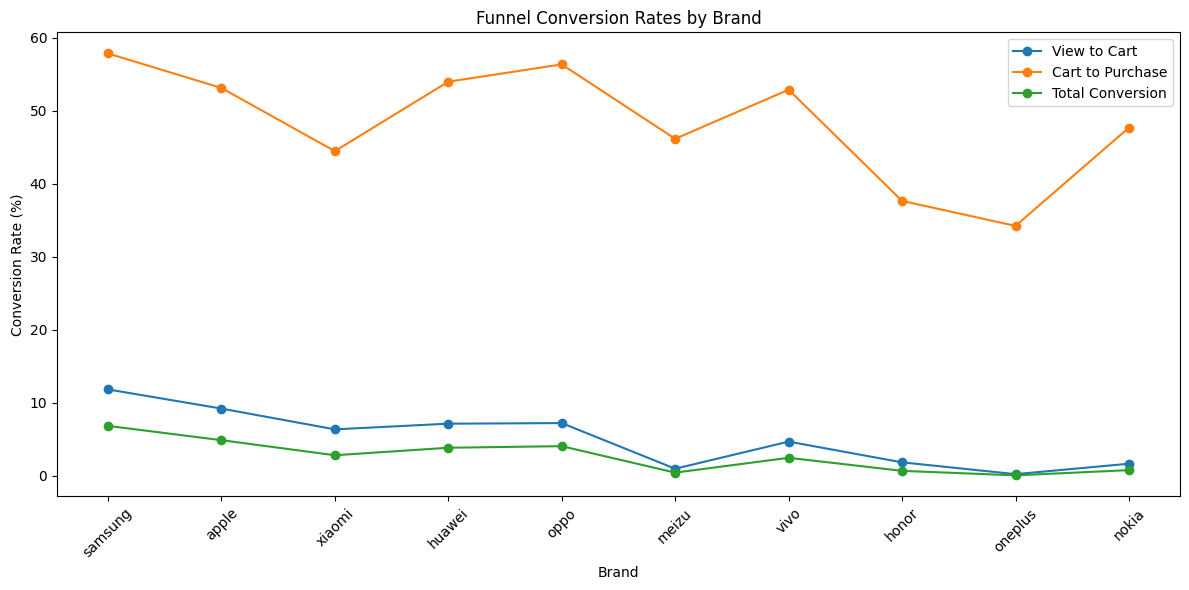

In [24]:
top10_funnel = brand_analysis.sort_values(
    by='view_sessions', ascending=False
).head(10)

x = range(len(top10_funnel))

plt.figure(figsize=(12, 6))
plt.plot(x, top10_funnel['view_to_cart_rate'], marker='o', label='View to Cart')
plt.plot(x, top10_funnel['cart_to_purchase_rate'], marker='o', label='Cart to Purchase')
plt.plot(x, top10_funnel['total_conversion_rate'], marker='o', label='Total Conversion')

plt.xticks(x, top10_funnel['brand'], rotation=45)
plt.title('Funnel Conversion Rates by Brand')
plt.xlabel('Brand')
plt.ylabel('Conversion Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

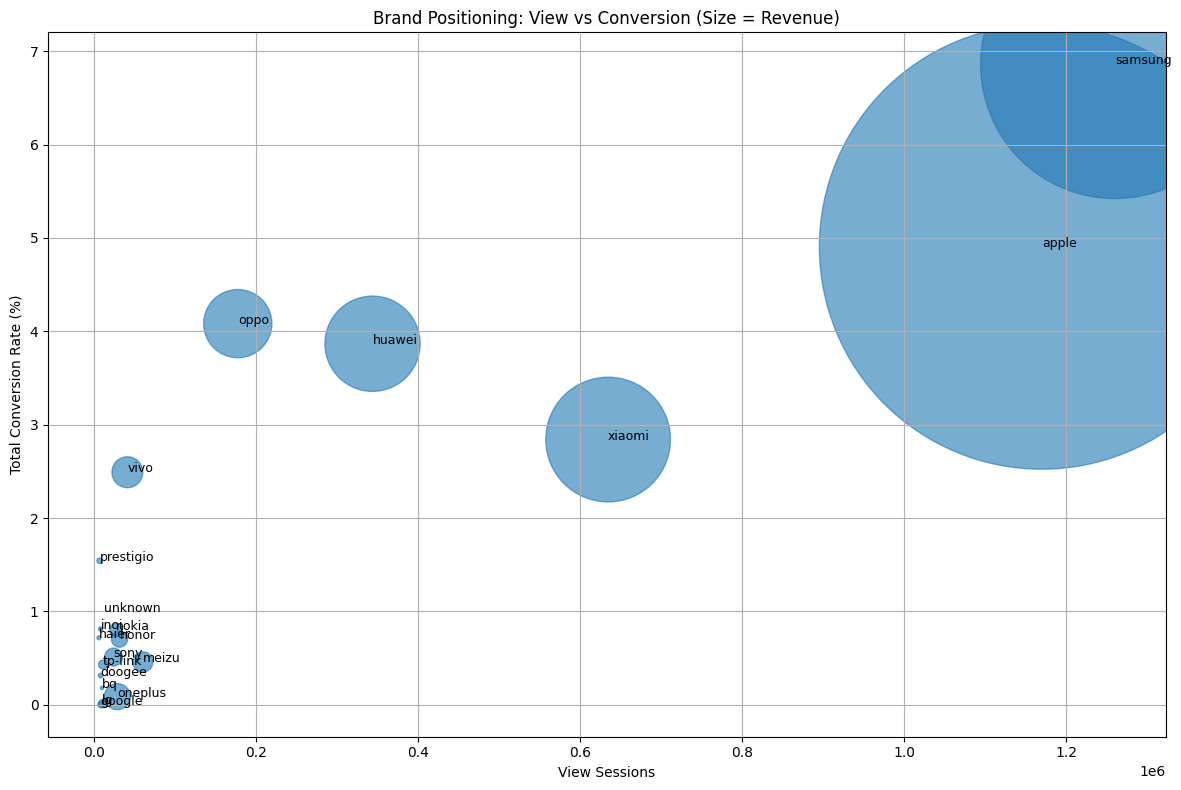

In [26]:
import matplotlib.pyplot as plt

# 상위 브랜드만 (노이즈 제거)
plot_df = brand_analysis.sort_values(
    by='view_sessions', ascending=False
).head(20).copy()

plt.figure(figsize=(12, 8))

plt.scatter(
    plot_df['view_sessions'],                 # X축: 조회 수
    plot_df['total_conversion_rate'],        # Y축: 전환율
    s=plot_df['revenue'] / 1000,             # 점 크기: 매출 (스케일 조정)
    alpha=0.6
)

# 브랜드 이름 표시
for i, row in plot_df.iterrows():
    plt.text(
        row['view_sessions'],
        row['total_conversion_rate'],
        row['brand'],
        fontsize=9
    )

plt.xlabel('View Sessions')
plt.ylabel('Total Conversion Rate (%)')
plt.title('Brand Positioning: View vs Conversion (Size = Revenue)')
plt.grid(True)
plt.tight_layout()
plt.show()

x축 -> view 
y축 -> 구매율
점 크기 -> revenue

-삼성
조회 많고 전환율 높으며 매출(단가x)도 크다 -> 시장 지배형 브랜드 (대중성+효율)
-애플
조회 많고 전환율 높으며 매출(단가x)이 압도적 -> 프리미엄 수익형 브랜드 (고가 전략..?)
-샤오미
조회 많으나 전환율 낮음 -> 관심 대비 성과 낮은 브랜드 (구매 전환 실패)

“브랜드에 따라 구매 결정 구조가 다르다” (유저 행동을 확인해야함)

애플 → 신뢰 기반 구매
삼성 → 대중형 구매
샤오미 → 탐색형 소비

3종 브랜드 비교 근거로 제시..?

In [27]:
target_brands = ['apple', 'samsung', 'xiaomi']

compare_df = brand_analysis[
    brand_analysis['brand'].str.lower().isin(target_brands)
].copy()

compare_df

,brand,view_sessions,view_to_cart_sessions,cart_to_purchase_sessions,view_to_cart_rate,cart_to_purchase_rate,total_conversion_rate,drop_view_to_cart,drop_cart_to_purchase,revenue,purchase_count,avg_price
27,samsung,1260159,149394,86443,11.855171,57.862431,6.859690,88.144829,42.137569,3.737366e+07,143123.0,261.129673
0,apple,1169945,108004,57385,9.231545,53.132291,4.904931,90.768455,46.867709,1.025490e+08,115345.0,889.063293
36,xiaomi,634709,40529,18029,6.385446,44.484197,2.840514,93.614554,55.515803,8.059770e+06,38776.0,207.854606


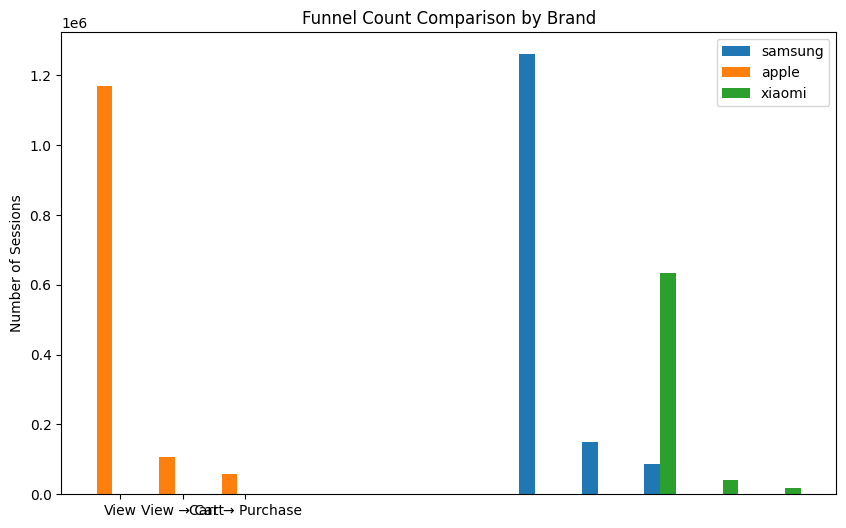

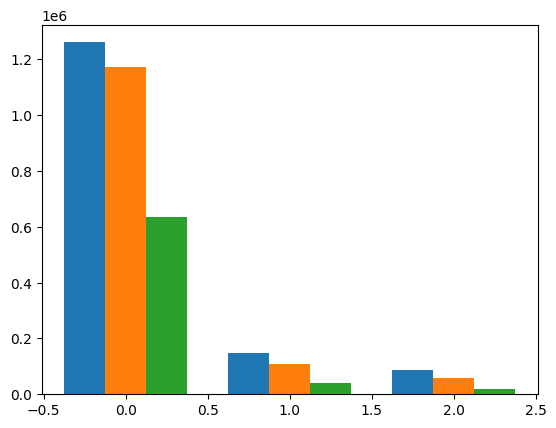

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# 퍼널 단계
stages = ['View', 'View → Cart', 'Cart → Purchase']
x = np.arange(len(stages))
width = 0.25

plt.figure(figsize=(10,6))

for i, row in compare_df.iterrows():
    values = [
        row['view_sessions'],
        row['view_to_cart_sessions'],
        row['cart_to_purchase_sessions']
    ]
    
    plt.bar(x + i*width, values, width, label=row['brand'])

# x축 위치 가운데 정렬
plt.xticks(x + width, stages)

plt.ylabel('Number of Sessions')
plt.title('Funnel Count Comparison by Brand')
plt.legend()
plt.show()
for i, row in enumerate(compare_df.itertuples()):
    values = [
        row.view_sessions,
        row.view_to_cart_sessions,
        row.cart_to_purchase_sessions
    ]
    plt.bar(x + (i-1)*width, values, width, label=row.brand)

유저별 구매여정

In [25]:
df_user_flow = df.sort_values(['user_id', 'event_time'])